# Plot polar maps of boreal domain data 
Paul Montesano  
Fall 2022  
run this notebook in a conda R env

In [1]:
#system("conda activate r-with-gdal")

In [1]:
library(aws.s3)
#library(rgdal)
library(raster)
library(tidyverse)
library(dplyr)
library(grid)
library(gridExtra)
library(RColorBrewer)
library(data.table)

library(fs)
library(sf)
#library(rgdal)

library(rgeos)
library(mapproj)
#library(rgee)
library(viridis)
#library(wesanderson)
library(scales)
library(tools)
library(patchwork)

library(rnaturalearth)
library(rnaturalearthdata)
#library(feather)
library(terra)
#conda install -c conda-forge r-rnaturalearth r-rnaturalearthdata r-mapproj r-rgeos r-viridis r-wesanderson r-patchwork r-aws.s3 r-feather r-rockchalk

Loading required package: sp

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ tidyr::extract() masks raster::extract()
✖ dplyr::filter()  masks stats::filter()
✖ dplyr::lag()     masks stats::lag()
✖ dplyr::select()  masks raster::select()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine



Attaching package: ‘data.table’


The following objects are masked from ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year


The following objects are masked from ‘package:dplyr’:

    between, first, 

### Paths

#### Set gpkg filenames

In [17]:
boreal_tile_DAAC_path = '/projects/shared-buckets/montesano/databank/daac/v3.0/boreal_tiles_v004_AGB_H30_2020_ORNLDAAC.gpkg'
WWF_ECO_FN = '/projects/my-public-bucket/databank/wwf_terr_ecos.gpkg'
BOREAL_EXTENT_FN = '/projects/my-public-bucket/databank/arc/wwf_circumboreal_Dissolve.gpkg'
HYBAS_LEV02_FN = '/projects/my-public-bucket/databank/hydrobasins/hybas_si_lev02_v1c.gpkg'

## Set output figure dir.

In [18]:
MAINDIR = '/projects/my-public-bucket/boreal_AGB'
OUT_FIGURE_DIR = paste0(MAINDIR, '/paper_figs')
OUT_DATA_DIR = paste0(MAINDIR, '/data')

### Mapping functions and vars

In [26]:
source('/projects/code/3dsi/boreal_map_functions.R') 
source('/projects/code/maap_tools/notebooks/boreal_smry_functions.r') 

[1] "MAAP"
[1] "MAAP"


#### Note: the ability to make these maps is changing...

The use of type 'SpatialPolygons' will go away.  
This means 'crop' will need to be changed to crop an 'sf' object.

But the whole polar mapping function is built around the use of 'SP', not 'sf'.-  

THis will need work and testing to be able to reproduce these polar maps.

At the moment, these still works in `r-env-3.6.3` on Prism

In [20]:
# Circ map new: trying to combine the best of the sf and sp approaches
DO_MAP_BOREAL_SP <- function( MAP_EXTENT = extent(-180,180,45,90), xlim=NULL, ylim=NULL, rotate_map=0, proj_name = 'azequalarea', LAYER_LIST=NULL, 
                             BOREAL_SHP_FN = '/projects/my-public-bucket/misc_files/Ecoregions2017_boreal_m.shp'){
  #
  # Map with a polar projection
  #
  
  # Color scale help
  #https://biostats.w.uib.no/color-scale-for-continuous-variables/
  
  #source(path("C:\\Users\\pmontesa\\Google Drive\\Work\\R","plot_functions.R"))
  # Shapefiles
  
  
  #world <- crop(ne_countries(scale = "medium", returnclass = "sp"), MAP_EXTENT)
  world <- raster::crop(as(ne_countries(scale = "medium", returnclass = "sf"), 'Spatial'), MAP_EXTENT)
  #world = st_crop(x = ne_countries(scale = "medium", returnclass = "sf") %>% st_make_valid() ,  y = ext)
  
  # WWF
  #boreal <- shp_fort_join("D:\\databank\\wwf\\arc\\wwf_circumboreal_Dissolve.shp", MAP_EXTENT, REPROJECT = TRUE)
  # TerraPulse
  boreal <- shp_fort_join(boreal_shp_fn, MAP_EXTENT, REPROJECT = TRUE)
  
  map_list_base = list(
    
    geom_polygon(data = fortify(world), aes(x = long, y = lat, group = group), fill="grey90", color=NA),
    geom_polygon(data = boreal, aes(x = long, y = lat, group = group), color=NA, fill="grey70"))
    
  map_list_top = list(
    
    geom_polygon(data = fortify(world), aes(x = long, y = lat, group = group), fill=NA, color="black", size=0.1 ),
    
    theme_minimal() , 
    theme(axis.text = element_blank(), axis.title = element_blank() ) ,
    
    #geom_polygon(data = fortify(continents.df_stereo), aes(x = long, y = lat, group = group), fill = NULL, colour = "black", size=0.25) +
    #scale_color_distiller(palette = "Greens", direction = 1, name = "%"),
    #scale_color_manual(values = COLOR_PAL, name = map_str) ,
    guides(guide = guide_legend(direction = "horizontal", nrow=1, label.position = "bottom", title.position = "bottom") ) ,
    theme(legend.position="top",
          legend.title = element_text(size=9),
          #       legend.direction  = 'vertical',
          legend.key.width  = unit(1.0, "cm"),
          legend.key.height = unit(.25, "cm")  )
  )
  
  if(is.null(LAYER_LIST)){
    map_list = list(
      map_list_base,
      map_list_top
    )
  }else{
    map_list = list(
      map_list_base,
      LAYER_LIST,
      map_list_top
    )
  }
  
  p_map = ggplot() + map_list +
    #coord_map_stereo_list(proj_name = proj_name, min_lat = MAP_EXTENT[3], rotation=rotate_map, xlim = xlim, ylim = ylim)
    coord_map_stereo_list(proj_name = proj_name, min_lat = MAP_EXTENT[3], rotation=rotate_map)
  
  if(FALSE){
    out_plot_fn = paste0("D:/projects/3dsi/plots/map_boreal_",proj_name,"_", format(Sys.time(), "_%Y%m%d"),'.png')
    print(out_plot_fn)
    ggsave(plot = p_map ,
           file = out_plot_fn,
           device = 'png', dpi = 300, width = 5, height = 5)
  }
  #print(p_map)
  return(p_map)
  
}

coord_map_stereo_list <- function(proj_name = "stereo", rotation = 0, min_lat = 50, xlims=NULL, ylims=NULL, LABEL_SIZE=3){ 
  
  # Defines the x axes required
  lat_lines = seq(min_lat+10, 80, by = 10)
  lat_labs = paste0(seq(min_lat+10, 80, by = 10), "\u00B0N")
  
  lon_lines = seq(0, 330, by = 30)
  lon_labs = c("0", paste0(seq(30, 150, by = 30), "°E"), "180", rev(paste0(seq(30, 150, by = 30), "°W")))
  
  
  return(list(
    # Convert to polar coordinates
    coord_map(proj_name, orientation = c(90, 0, rotation, xlims=xlims, ylims=ylims)), #"ortho""
    scale_y_continuous(breaks = seq(45, 90, by = 5), labels = NULL),
    
    # Removes Axes and labels
    scale_x_continuous(breaks = NULL),
    xlab(""),
    ylab(""),
    
    # Adds axes
    # Latitude
    geom_hline(aes(yintercept = lat_lines), size = 0.25, color = "grey80", linetype = "dotted"),
    # Outer circular border
    geom_hline(aes(yintercept = min_lat), size = 0.25), #1
    # Longitude
    geom_vline(aes(xintercept = lon_lines), size = 0.25, color = "grey80", linetype = "dotted"),
    #geom_segment(aes(y = 45, yend = 85, x = x_lines, xend = x_lines), linetype = "dotted") +
    
    # Adds labels
    #geom_text(aes(x = 0, y = lat_lines, hjust = 0.5, label = lat_labs)),
    geom_label(aes(x = 0, y = lat_lines, label = lat_labs), label.size = NA, size=LABEL_SIZE, color = "black", fill="white", label.padding=unit(0.1,"lines")),
    #geom_text(aes(x = lon_lines, y = min_lat-3, hjust = 0.5, vjust = 0.5, label = lon_labs), size = 2.5), #hjust = 0.5
    # min-3 so lon labels are centered over outer line
    geom_label(aes(x = lon_lines, y = min_lat-3, label = lon_labs), label.size = NA,  hjust='inward', vjust='inward', size = LABEL_SIZE, color = "black", fill="white", label.padding=unit(0.1,"lines")),  #y = min_lat-3 why used to be this?
    
    ##guides(fill=FALSE)+
    
    # Change theme to remove axes and ticks
    theme(panel.background = element_blank(),
          #panel.grid = element_line(size = 0.25, linetype = 'dotted', colour = "grey50"),
          axis.ticks=element_blank())
    #,
    #labs(caption = "Source: circ_tte_map.Rmd")
  ))
}  

gridCreate<-function(shp, res,proj_out, buffer=10000){
  
  if (!is.null(buffer)){
    shp<-buffer(shp, width=buffer)
  }
  ext <- floor(extent(shp))
  rr <- raster(ext, res=res)
  rr <- rasterize(shp, rr, field=1)
  rr[!is.na(rr[])]<-1:length(rr[!is.na(rr[])])
  grid<-rasterToPolygons(rr)
  crs(grid)<-projection(shp)
  if (!proj_out==projection(shp)){
    grid<-spTransform(grid,CRS(proj_out))
  }
  return(grid)  
}



In [21]:
crs_canalb = "+proj=aea +lat_0=40 +lon_0=180 +lat_1=50 +lat_2=70 +x_0=0 +y_0=0 +datum=NAD83 +units=m +no_defs"
crs_albers = "+proj=aea +lat_1=50 +lat_2=70 +lat_0=40 +lon_0=180 +x_0=0 +y_0=0 +ellps=GRS80 +datum=NAD83 +units=m +no_defs"
crs_gcs = "+proj=longlat +ellps=WGS84 +datum=WGS84 +no_defs"

### Get Boreal EXTENT

#### Read boreal extent, read tiles, then clip tiles to boreal extent

In [22]:
boreal_shp_fn = '/projects/shared-buckets/nathanmthomas/analyze_agb/input_zones/wwf_circumboreal_Dissolve.geojson'
boreal = st_read(boreal_shp_fn)
boreal_albers<-spTransform(sf:::as_Spatial(boreal),CRS(crs_albers))

Reading layer `wwf_circumboreal_Dissolve' from data source 
  `/projects/shared-buckets/nathanmthomas/analyze_agb/input_zones/wwf_circumboreal_Dissolve.geojson' 
  using driver `GeoJSON'
Simple feature collection with 2 features and 4 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -164.95 ymin: 44.39544 xmax: 169.9216 ymax: 71.41746
Geodetic CRS:  WGS 84


#### Get all tiles delivered to DAAC for this project

In [11]:
tte_tiles_DAAC_path = '/projects/shared-buckets/montesano/databank/tte_tiles.gpkg'
tiles_gcs_DAAC = st_read(tte_tiles_DAAC_path) %>% st_transform(4326)
tile_num_DAAC_list =  tiles_gcs_DAAC %>% as.data.frame() %>% dplyr::select(tile_num) %>% as.list()
tile_num_DAAC_list = unlist(tile_num_DAAC_list[[1]])
length(tile_num_DAAC_list)

Reading layer `tte_tiles' from data source 
  `/projects/shared-buckets/montesano/databank/tte_tiles.gpkg' 
  using driver `GPKG'
Simple feature collection with 4809 features and 4 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: -180.0004 ymin: 45.00014 xmax: 179.9998 ymax: 75.00014
Geodetic CRS:  WGS 84


[1] 4809

#### Clip tiles to Boreal EXTENT

In [12]:
# boreal_tile_index_path = '/projects/shared-buckets/montesano/databank/boreal_tiles_v004.gpkg'
# boreal_tiles_clip = st_intersection(
#                                 st_read(boreal_tile_index_path) %>% st_transform(crs="+proj=longlat +ellps=WGS84 +datum=WGS84 +no_defs"), 
#                                 boreal)#%>% as.data.frame()

## Map showing boreal tile extent

In [13]:
ext = extent(-180,180,45,90)

In [14]:
ext = raster::extent(-180,180,40,90)

In [15]:
#boreal_tiles_gcs = shp_fort_join(boreal_tile_index_path, ext, REPROJECT=TRUE)

In [23]:
wwf_ecoregions = shp_fort_join(WWF_ECO_FN, ext, REPROJECT=TRUE)

[1] "Using sf and coercing to Spatial object..."
Reading layer `wwf_terr_ecos' from data source 
  `/projects/my-public-bucket/databank/wwf_terr_ecos.gpkg' using driver `GPKG'
Simple feature collection with 14458 features and 18 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: -180 ymin: -89.89197 xmax: 180 ymax: 83.62313
Geodetic CRS:  WGS 84


Warning message:
“`fortify(<SpatialPolygonsDataFrame>)` was deprecated in ggplot2 3.4.4.
ℹ Please migrate to sf.”
Regions defined for each Polygons


In [59]:
wwf_ecoregion_biome6 = st_read('/projects/my-public-bucket/databank/wwf_terr_ecos.gpkg')  %>% filter(BIOME == 6)

Reading layer `wwf_terr_ecos' from data source 
  `/projects/my-public-bucket/databank/wwf_terr_ecos.gpkg' using driver `GPKG'
Simple feature collection with 14458 features and 18 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: -180 ymin: -89.89197 xmax: 180 ymax: 83.62313
Geodetic CRS:  WGS 84


In [60]:
st_write(wwf_ecoregion_biome6, '/projects/my-public-bucket/databank/wwf_terr_ecos_biome6.gpkg')

Writing layer `wwf_terr_ecos_biome6' to data source 
  `/projects/my-public-bucket/databank/wwf_terr_ecos_biome6.gpkg' using driver `GPKG'
Writing 427 features with 18 fields and geometry type Polygon.


In [52]:
#boreal_extent= st_read(BOREAL_EXTENT_FN)
#wwf_ecoregion = st_read('/projects/my-public-bucket/databank/wwf_terr_ecos.gpkg') %>% st_transform(crs=crs(boreal_extent)) 

In [27]:
boreal_ecoregions = get_boreal_ecoregions(BOREAL_EXTENT_FN, WWF_ECO_FN)
boreal_ecoregion_names = levels(factor(boreal_ecoregions$ECO_NAME))
length(boreal_ecoregion_names)

Reading layer `wwf_circumboreal_Dissolve' from data source 
  `/projects/my-public-bucket/databank/arc/wwf_circumboreal_Dissolve.gpkg' 
  using driver `GPKG'
Simple feature collection with 2 features and 4 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -5281040 ymin: -60527.9 xmax: 3959203 ymax: 8747447
Projected CRS: NAD83 / Alaska Albers
Reading layer `wwf_terr_ecos' from data source 
  `/projects/my-public-bucket/databank/wwf_terr_ecos.gpkg' using driver `GPKG'
Simple feature collection with 14458 features and 18 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: -180 ymin: -89.89197 xmax: 180 ymax: 83.62313
Geodetic CRS:  WGS 84


Warning message:
“attribute variables are assumed to be spatially constant throughout all geometries”


[1] "/projects/my-public-bucket/databank/arc/wwf_boreal_ecoregions.gpkg"


[1] 42

In [28]:
#hydrobasin_si_lev02 = shp_fort_join(HYBAS_LEV02_FN, ext, REPROJECT=TRUE)

In [29]:
# Function to sort ecoregion factor by longitude
sort_ecoregions_by_longitude <- function(df, eco_column = "ecoregions_ECO_NAME", sortby_column = "long") {
  
  # Check if required columns exist
  if(!eco_column %in% colnames(df)) {
    stop(paste("Ecoregion column", eco_column, "not found in dataframe"))
  }
  if(!sortby_column %in% colnames(df)) {
    stop(paste(sortby_column, "not found in dataframe"))
  }
  
  # Method 1: Using forcats::fct_reorder() 
  # This handles the case where there are multiple longitude values per ecoregion
  df[[eco_column]] <- forcats::fct_reorder(df[[eco_column]], df[[sortby_column]])
  
  return(df)
}

In [37]:
wwf_ecoregions_in_summary = wwf_ecoregions  %>%
    dplyr::mutate(ecoregions_ECO_NAME = factor(ECO_NAME)) %>%
    dplyr::filter(ecoregions_ECO_NAME %in% levels(factor(boreal_ecoregions$ECO_NAME))) %>%
    droplevels()

# # Step 1: Sort ecoregions by longitude (ascending)
# sorted_ecoregions <- sort_ecoregions_by_longitude(wwf_ecoregions_in_summary)  

# # Step 2: Create an ordered factor based on the sorted ecoregions
# ecoregion_order <- levels(sorted_ecoregions$ecoregions_ECO_NAME)

# # # Apply the same ordering to the pixel and summary dfs
# #pixel_df$ecoregions_ECO_NAME <- factor(pixel_df$ecoregions_ECO_NAME, levels = ecoregion_order)
# summary_df$ecoregions_ECO_NAME <- factor(summary_df$ecoregions_ECO_NAME, levels = ecoregion_order)
# length(levels(summary_df$ecoregions_ECO_NAME))

In [38]:
head(wwf_ecoregions_in_summary)

,long,lat,order,hole,piece,id,group,OBJECTID,AREA,PERIMETER,⋯,GBL_STAT,G200_REGIO,G200_NUM,G200_BIOME,G200_STAT,Shape_Leng,Shape_Area,area_km2,eco_code,ecoregions_ECO_NAME
,<dbl>,<dbl>,<int>,<lgl>,<fct>,<chr>,<fct>,<int>,<dbl>,<dbl>,⋯,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<fct>
1,30.60972,61.50903,1,FALSE,1,1,1.1,5649,6.816196,0.153,⋯,1,NA,0,0,0,0.1528742,0.001148822,2170288,PA0608,Scandinavian and Russian taiga
2,30.59639,61.49654,2,FALSE,1,1,1.1,5649,6.816196,0.153,⋯,1,NA,0,0,0,0.1528742,0.001148822,2170288,PA0608,Scandinavian and Russian taiga
3,30.58638,61.49236,3,FALSE,1,1,1.1,5649,6.816196,0.153,⋯,1,NA,0,0,0,0.1528742,0.001148822,2170288,PA0608,Scandinavian and Russian taiga
4,30.57666,61.49181,4,FALSE,1,1,1.1,5649,6.816196,0.153,⋯,1,NA,0,0,0,0.1528742,0.001148822,2170288,PA0608,Scandinavian and Russian taiga
5,30.56972,61.49737,5,FALSE,1,1,1.1,5649,6.816196,0.153,⋯,1,NA,0,0,0,0.1528742,0.001148822,2170288,PA0608,Scandinavian and Russian taiga
6,30.56083,61.50237,6,FALSE,1,1,1.1,5649,6.816196,0.153,⋯,1,NA,0,0,0,0.1528742,0.001148822,2170288,PA0608,Scandinavian and Russian taiga


In [41]:
exozones_fao_fn = "/projects/shared-buckets/leitoldv/AOIs/BOREAL/FAO_ecozones_all.gpkg"
exozones_fao = shp_fort_join(exozones_fao_fn, ext, REPROJECT=TRUE)
exozones_fao_boreal_fn = "/projects/shared-buckets/leitoldv/AOIs/BOREAL/FAO_ecozones_boreal.gpkg"
exozones_fao_boreal = shp_fort_join(exozones_fao_boreal_fn, ext, REPROJECT=TRUE)

[1] "Using sf and coercing to Spatial object..."


Warning message in CPL_read_ogr(dsn, layer, query, as.character(options), quiet, :
“GDAL Message 1: unable to open database file: this file is a WAL-enabled database. It cannot be opened because it is presumably read-only or in a read-only directory. Retrying with IMMUTABLE=YES open option”


Reading layer `eco_zone' from data source 
  `/projects/shared-buckets/leitoldv/AOIs/BOREAL/FAO_ecozones_all.gpkg' 
  using driver `GPKG'
Simple feature collection with 13620 features and 7 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -180 ymin: -90 xmax: 180 ymax: 83.6236
Geodetic CRS:  Undefined geographic SRS


Regions defined for each Polygons


[1] "Using sf and coercing to Spatial object..."


Warning message in CPL_read_ogr(dsn, layer, query, as.character(options), quiet, :
“GDAL Message 1: unable to open database file: this file is a WAL-enabled database. It cannot be opened because it is presumably read-only or in a read-only directory. Retrying with IMMUTABLE=YES open option”


Reading layer `eco_zone' from data source 
  `/projects/shared-buckets/leitoldv/AOIs/BOREAL/FAO_ecozones_boreal.gpkg' 
  using driver `GPKG'
Simple feature collection with 1090 features and 7 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -180 ymin: 45.53229 xmax: 180 ymax: 72.26111
Geodetic CRS:  Undefined geographic SRS


Regions defined for each Polygons


In [58]:
head(wwf_ecoregions_in_summary %>% select(BIOME))

,BIOME
,<dbl>
1,6
2,6
3,6
4,6
5,6
6,6


In [ ]:
DO_MAP_BOREAL_SP()

In [62]:
options(repr.plot.width = 10, repr.plot.height = 10, repr.plot.res = 250)

m_list = list()
names_list = c('Boreal + Transitional Ecoregions (WWF)', 
               'Boreal Ecoregions (WWF)',
               'Boreal Ecoregions (FAO)'
               #, 'Ecoregions (FAO)'
              )
cnt = 0

for(BOREAL_FN in c(
                    wwf_circ_dis_fn 
                   , '/projects/my-public-bucket/databank/wwf_terr_ecos_biome6.gpkg'
                   , exozones_fao_boreal_fn 
                   #, exozones_fao_fn
                  )
   ){
    cnt = cnt + 1
    m_base = DO_MAP_BOREAL_SP(MAP_EXTENT=ext,  
                         BOREAL_SHP_FN = BOREAL_FN
                         # LAYER_LIST = list(
                         #     geom_polygon(data=wwf_ecoregions_in_summary, 
                         #                  aes(x=long, y=lat, group=group, fill=ECO_NAME), size=0.1),
                         #     scale_fill_grey(start=0.25, end=0, name=NULL), # the dark end
                         #     scale_fill_manual(values=ecoregion_colors, name="Ecoregion", guide=FALSE)
                         #     # geom_polygon(data=boreal_tiles_DAAC_gcs, aes(x=long, y=lat, group=group), size=0.1, fill=NA, color='dodgerblue'),
                         #     # geom_polygon(data=boreal_tiles_DAAC_gcs %>% filter(tile_num %in% TILE_NUM_LIST), aes(x=long, y=lat, group=group), 
                         #     #              alpha=0.15, size=0.1, fill='black', color='white')
                         #     #,geom_polygon(data = hydrobasin_si_lev02, aes(x = long, y = lat, group = group), size=0.1, fill=NA, color='black') 
                         #     #,
                         #     #, geom_text(data = boreal_tiles_DAAC_gcs %>% filter(tile_num %in% TILE_NUM_LIST) %>% group_by(tile_num) %>%
                         #     #      summarize(long = mean(long),
                         #     #                lat = mean(lat)),
                         #     #      aes(x = long, y = lat, label = tile_num), size = 2.5, fontface = "bold")
                         # ) #, fill=NA
                        ) + 
        theme(legend.text=element_text(size=rel(0.5))) +
        labs(title = names_list[cnt])
    m_list[[cnt]] = m_base

}

[1] "Using sf and coercing to Spatial object..."
Reading layer `wwf_circumboreal_Dissolve' from data source 
  `/projects/my-public-bucket/databank/arc/wwf_circumboreal_Dissolve.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 2 features and 4 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -5281040 ymin: -60527.9 xmax: 3959203 ymax: 8747447
Projected CRS: NAD83 / Alaska Albers


Regions defined for each Polygons
Regions defined for each Polygons
Regions defined for each Polygons


[1] "Using sf and coercing to Spatial object..."
Reading layer `wwf_terr_ecos_biome6' from data source 
  `/projects/my-public-bucket/databank/wwf_terr_ecos_biome6.gpkg' 
  using driver `GPKG'
Simple feature collection with 427 features and 18 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: -164.9503 ymin: 45.53015 xmax: 169.9216 ymax: 71.41746
Geodetic CRS:  WGS 84


Regions defined for each Polygons
Regions defined for each Polygons
Regions defined for each Polygons


[1] "Using sf and coercing to Spatial object..."


Warning message in CPL_read_ogr(dsn, layer, query, as.character(options), quiet, :
“GDAL Message 1: unable to open database file: this file is a WAL-enabled database. It cannot be opened because it is presumably read-only or in a read-only directory. Retrying with IMMUTABLE=YES open option”


Reading layer `eco_zone' from data source 
  `/projects/shared-buckets/leitoldv/AOIs/BOREAL/FAO_ecozones_boreal.gpkg' 
  using driver `GPKG'
Simple feature collection with 1090 features and 7 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -180 ymin: 45.53229 xmax: 180 ymax: 72.26111
Geodetic CRS:  Undefined geographic SRS


Regions defined for each Polygons
Regions defined for each Polygons
Regions defined for each Polygons


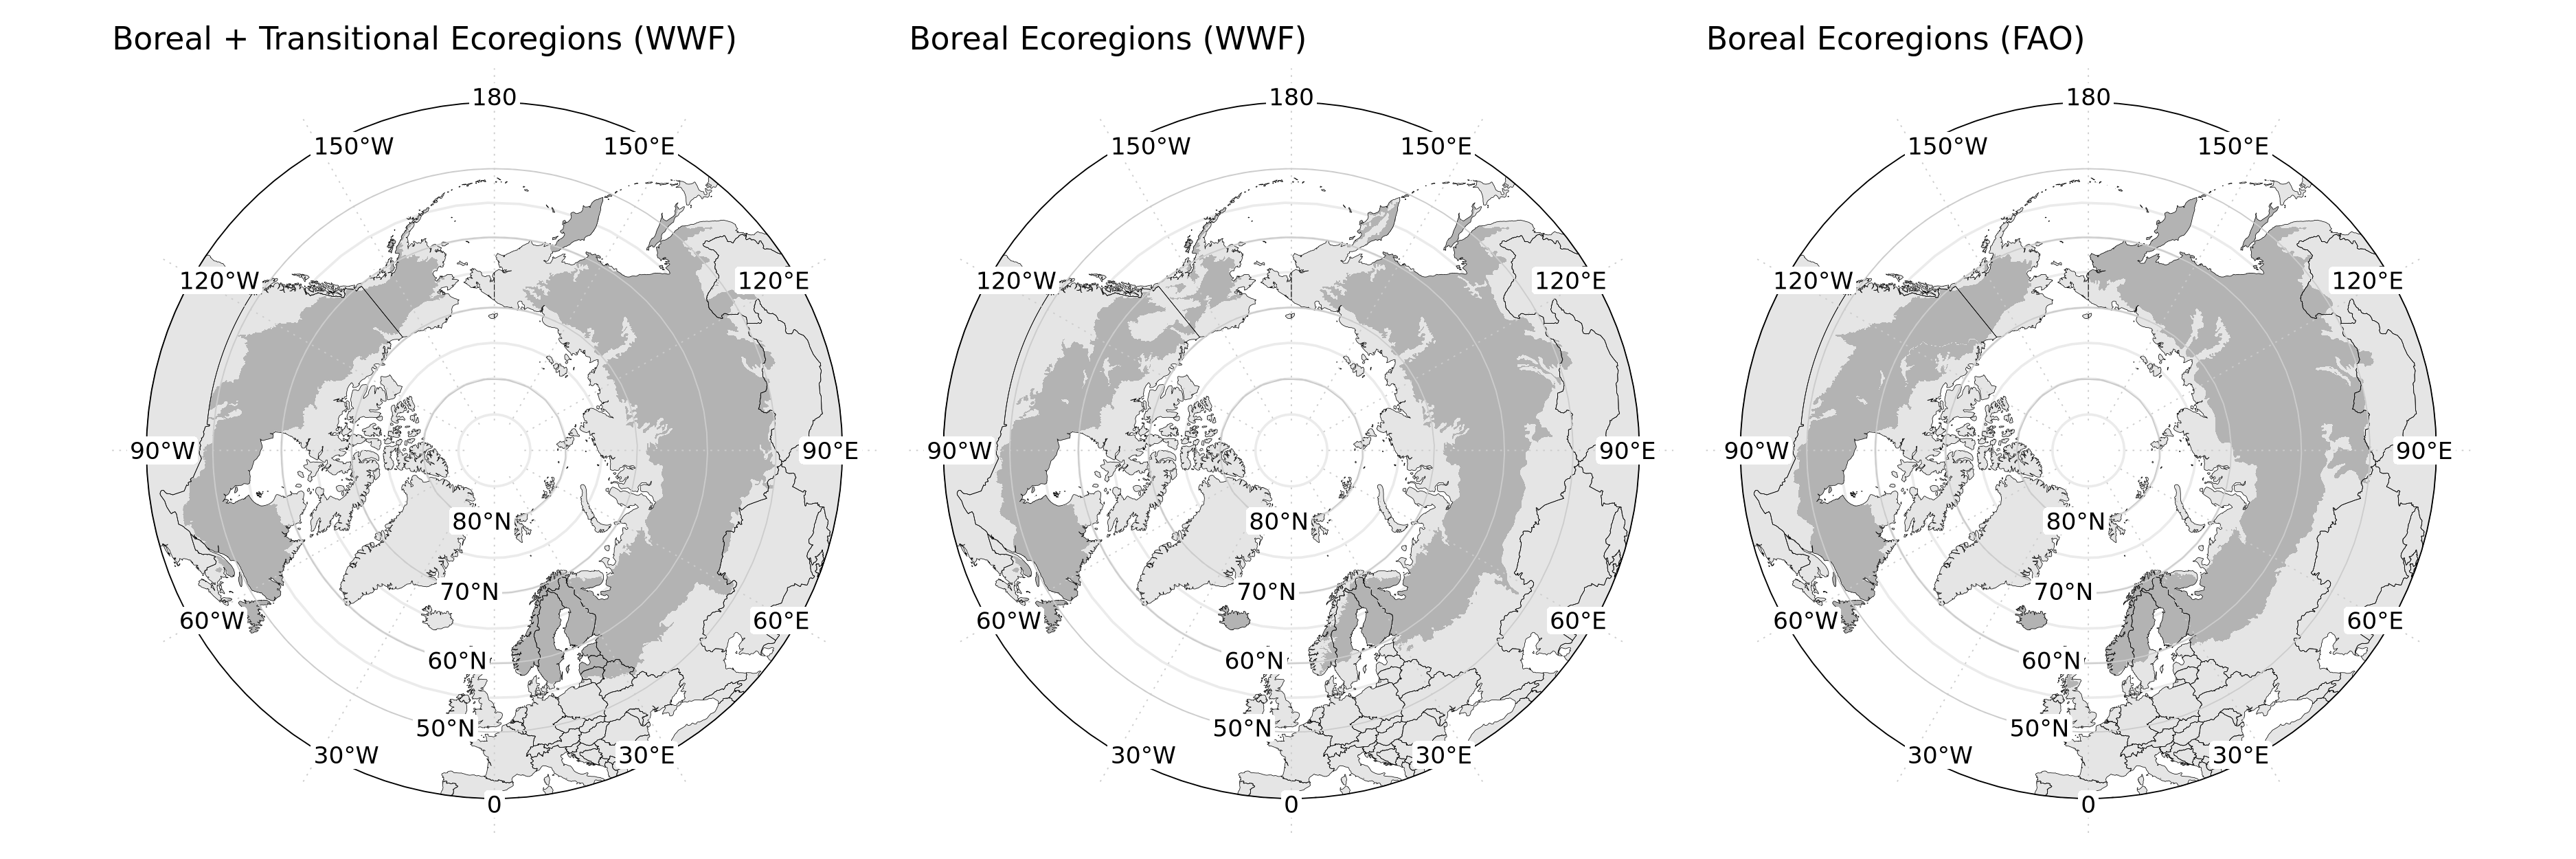

In [63]:
options(repr.plot.width = 15, repr.plot.height = 5, repr.plot.res = 250)

m_list[[1]] | m_list[[2]] | m_list[[3]]

## Export figure:

In [15]:
DATA_NAME_STEM = "ecoregions"
EXPORT_TIME_STR = format(Sys.time(), "_%Y%m%d")

for(OUT_TYPE in c('png', 'pdf')){
    map_fn = path(OUT_FIGURE_DIR, paste0("map_",DATA_NAME_STEM,"_", EXPORT_TIME_STR,".", OUT_TYPE))
    print(map_fn)
    ggsave(plot = m_boreal_tiles, create.dir = TRUE,
           file = map_fn,
           device = OUT_TYPE, dpi = 300, width = 8, height = 15)
}

/projects/my-public-bucket/tte_map/daac_figs/map_tte_tiles_DAAC__20251116.png
/projects/my-public-bucket/tte_map/daac_figs/map_tte_tiles_DAAC__20251116.pdf
